# 00 — Pump + Dump: объединение двух стримов

Pump-fade (SHORT после +5%/15m) и dump-bounce (LONG после −7%/15m) —
механически ПРОТИВОПОЛОЖНЫЕ reversion-стримы. Гипотеза (юзер): они некоррелированы
и, возможно, хеджируют худшие режимы друг друга (шорты пампов страдают в melt-up,
лонги дампов — в крахе; это противоположные режимы) → комбинация = глаже кривая
и ниже просадка.

Оба стрима — ОДНА машинерия (scale-in, price-step fill, выход cluster_end+240,
net costs), зеркально по знаку, полная вселенная 173, 2024-2026. Базовые конфиги
(без классификатора/tail-лимитов) для чистого замера корреляции.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
WIN=15;H=240;COOLDOWN=10;N_MAX=10;FEE=0.00075;DELTA=0.02
THR_D=0.07   # dump: -7%/15m -> LONG
THR_P=0.05   # pump: +5%/15m -> SHORT

def clusters(c, thr, side):
    # side=-1 dump (ret<=-thr), side=+1 pump (ret>=+thr)
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond = (r<=-thr) if side<0 else (r>=thr)
    out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;falses=0;j=i+1
        while j<n:
            if cond[j]: last_true=j;falses=0
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true)); i=last_true+COOLDOWN+1
    return out

def fills(c,st,en,side):
    # price-step: dump adds when price drops dDELTA; pump adds when price rises dDELTA
    pos=[st]; lastc=c[st]; t=st+1
    while t<=en and len(pos)<N_MAX:
        trig = (c[t]<=lastc*(1-DELTA)) if side<0 else (c[t]>=lastc*(1+DELTA))
        if trig: pos.append(t); lastc=c[t]
        t+=1
    return pos

def stream(thr,side):
    rows=[]
    for s in list_symbols():
        try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
        except Exception: continue
        c=df["close"].to_numpy("float64"); ts=df.index; n=len(c)
        for (st,en) in clusters(c,thr,side):
            ex=en+1+H
            if st+1>=n or ex>=n: continue
            pos=[p for p in fills(c,st,en,side) if p+1<n]
            pr=np.array([c[p+1] for p in pos]); ws=np.arange(1,len(pr)+1,dtype=float); ws/=ws.sum()
            avg=(ws*pr).sum()
            raw=c[ex]/avg-1
            pnl=(raw if side<0 else -raw)-2*FEE   # long for dump, short for pump
            rows.append(dict(entry=ts[st+1],exit_ts=ts[ex],pnl=pnl))
    return pd.DataFrame(rows).sort_values("entry").reset_index(drop=True)

DUMP=stream(THR_D,-1); PUMP=stream(THR_P,+1)
print(f"DUMP (long -7%): {len(DUMP)} trades, mean {DUMP.pnl.mean()*100:+.2f}%, win {(DUMP.pnl>0).mean()*100:.1f}%")
print(f"PUMP (short +5%): {len(PUMP)} trades, mean {PUMP.pnl.mean()*100:+.2f}%, win {(PUMP.pnl>0).mean()*100:.1f}%")

DUMP (long -7%): 4374 trades, mean +5.23%, win 71.1%
PUMP (short +5%): 13567 trades, mean +0.02%, win 54.3%


In [2]:
PER=20.;START=1000.;MAX=50
def portfolio(df):
    df=df.sort_values("entry"); en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]"); pnl=df.pnl.values
    cash=START;openh=[];eq_t=[];eq_v=[]
    for i in range(len(pnl)):
        now=en[i]
        while openh and openh[0][0]<=now:
            _,pn=heapq.heappop(openh);cash+=PER*pn;eq_t.append(now);eq_v.append(cash)
        if len(openh)<MAX: heapq.heappush(openh,(ex[i],pnl[i]))
    for _,pn in sorted(openh):cash+=PER*pn;eq_t.append(_);eq_v.append(cash)
    return pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index()

def daily(s):  # equity series -> daily equity (ffill flat days)
    s=s[~s.index.duplicated(keep="last")]
    return s.resample("1D").last().ffill()

eD=daily(portfolio(DUMP)); eP=daily(portfolio(PUMP))
# align on common daily index
idx=eD.index.union(eP.index)
eD=eD.reindex(idx).ffill().fillna(START); eP=eP.reindex(idx).ffill().fillna(START)
eC=eD+eP  # 50/50 combined sleeves ($1000 each = $2000 book)

def met(eq, start):
    r=eq.pct_change().dropna(); span=(eq.index[-1]-eq.index[0]).days/365.25
    tot=eq.iloc[-1]/start-1; cagr=(eq.iloc[-1]/start)**(1/span)-1
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    peak=np.maximum.accumulate(eq.values); dd=(eq.values/peak-1).min()
    return tot,cagr,sh,dd

rD=eD.pct_change().dropna(); rP=eP.pct_change().dropna()
common=rD.index.intersection(rP.index)
corr=np.corrcoef(rD.loc[common],rP.loc[common])[0,1]
print(f"=== daily-return correlation(DUMP, PUMP) = {corr:+.3f} ===\n")
rows=[]
for name,eq,st in [("DUMP only",eD,START),("PUMP only",eP,START),("COMBINED 50/50",eC,2*START)]:
    tot,cagr,sh,dd=met(eq,st)
    rows.append(dict(book=name,total=f"{tot*100:+.0f}%",CAGR=f"{cagr*100:+.1f}%",
                     Sharpe=round(sh,2),maxDD=f"{dd*100:.1f}%",Calmar=round(cagr/abs(dd),2)))
T=pd.DataFrame(rows); print(T.to_string(index=False))

=== daily-return correlation(DUMP, PUMP) = -0.349 ===

          book total   CAGR  Sharpe maxDD  Calmar
     DUMP only +125% +41.8%    1.99 -5.3%    7.90
     PUMP only +165% +51.9%    2.72 -8.6%    6.05
COMBINED 50/50 +145% +47.0%    4.12 -3.6%   12.91


In [3]:
# regime hedge: on DUMP's worst days, what did PUMP do? and vice versa
pnlD=daily(portfolio(DUMP)).diff().reindex(idx).fillna(0)
pnlP=daily(portfolio(PUMP)).diff().reindex(idx).fillna(0)
df=pd.DataFrame({"dump":pnlD,"pump":pnlP}).loc[(pnlD!=0)|(pnlP!=0)]
print("=== regime hedge check (daily $ PnL) ===")
print("DUMP worst 5 days -> what PUMP did:")
for d,row in df.sort_values("dump").head(5).iterrows():
    print(f"  {d:%Y-%m-%d}  dump {row.dump:+6.1f}$   pump {row.pump:+6.1f}$")
print("PUMP worst 5 days -> what DUMP did:")
for d,row in df.sort_values("pump").head(5).iterrows():
    print(f"  {d:%Y-%m-%d}  pump {row.pump:+6.1f}$   dump {row.dump:+6.1f}$")
both=(df.dump<0)&(df.pump<0)
print(f"\ndays BOTH negative: {both.sum()} of {len(df)} active days ({both.mean()*100:.1f}%)")
print(f"corr of daily $ PnL: {df.dump.corr(df.pump):+.3f}")

=== regime hedge check (daily $ PnL) ===
DUMP worst 5 days -> what PUMP did:
  2024-04-13  dump  -73.2$   pump   -0.8$
  2024-03-05  dump  -38.3$   pump +119.6$
  2026-04-19  dump  -33.0$   pump  +11.7$
  2025-03-23  dump  -22.7$   pump  +15.9$
  2026-03-29  dump  -17.4$   pump  +15.0$
PUMP worst 5 days -> what DUMP did:
  2025-02-03  pump -113.5$   dump   +0.0$
  2025-10-11  pump  -84.1$   dump +267.6$
  2024-12-20  pump  -76.6$   dump   +1.2$
  2025-03-02  pump  -71.0$   dump   -0.9$
  2024-08-05  pump  -66.8$   dump  +29.9$

days BOTH negative: 52 of 828 active days (6.3%)
corr of daily $ PnL: -0.366


[saved] notebooks\pump_dump_combined\_out\comb_00_equity.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_00_equity.png')

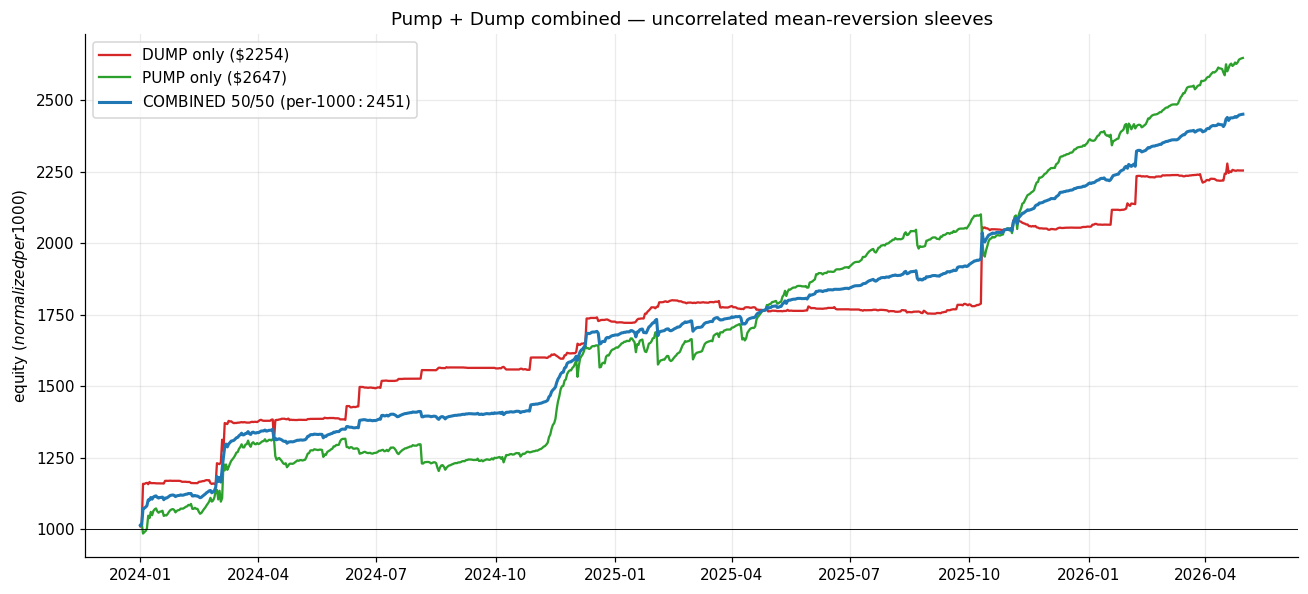

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5.5))
plt.plot(eD.index,eD.values,label=f"DUMP only (${eD.iloc[-1]:.0f})",color="#d62728")
plt.plot(eP.index,eP.values,label=f"PUMP only (${eP.iloc[-1]:.0f})",color="#2ca02c")
plt.plot(eC.index,eC.values/2,label=f"COMBINED 50/50 (per-$1000: ${eC.iloc[-1]/2:.0f})",color="#1f77b4",lw=2)
plt.axhline(START,color="k",lw=.6); plt.ylabel("equity $ (normalized per $1000)")
plt.title("Pump + Dump combined — uncorrelated mean-reversion sleeves")
plt.legend(); show("comb_00_equity")

## Как читать
- **Корреляция дневных доходностей** — близко к 0 или отрицательно = диверсификация
  работает. Главное число.
- **Таблица книг** — combined Sharpe должен быть ВЫШЕ каждого по отдельности, а
  combined maxDD — НИЖЕ (в % к капиталу), если стримы некоррелированы.
- **Regime hedge** — в худшие дни дампа пампы в плюсе? И наоборот? Доля дней, где
  ОБА в минусе — чем меньше, тем лучше хедж.

*Verdict после прогона. Базовые конфиги; классификатор/tail-лимиты — слой сверху позже.*